In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("diabetes_risk_dataset.csv")
df.head()

,age,bmi,glucose_level,physical_activity_level,family_history,smoker,at_risk_diabetes
0,58,33.154816,71.049867,low,0,0,1
1,71,26.786882,125.964887,low,0,0,0
2,48,20.977319,61.876196,moderate,1,1,0
3,34,27.959924,137.648074,low,0,0,0
4,62,28.304175,65.879564,moderate,0,0,0


In [4]:
df.tail()

,age,bmi,glucose_level,physical_activity_level,family_history,smoker,at_risk_diabetes
99995,74,28.001900,130.147993,low,0,0,0
99996,26,32.514707,141.784172,low,0,1,1
99997,71,26.504374,66.520077,moderate,0,0,0
99998,62,31.735351,105.753990,high,1,0,1
99999,61,30.627113,81.916400,high,0,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      100000 non-null  int64  
 1   bmi                      100000 non-null  float64
 2   glucose_level            100000 non-null  float64
 3   physical_activity_level  100000 non-null  object 
 4   family_history           100000 non-null  int64  
 5   smoker                   100000 non-null  int64  
 6   at_risk_diabetes         100000 non-null  int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 5.3+ MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.0,49.545230,17.310892,20.0,35.000000,49.000000,65.000000,79.0
bmi,100000.0,27.034009,4.957869,15.0,23.657095,27.002693,30.381817,45.0
glucose_level,100000.0,101.274228,27.608618,60.0,79.809212,100.023378,120.199707,200.0
family_history,100000.0,0.299320,0.457962,0.0,0.000000,0.000000,1.000000,1.0
smoker,100000.0,0.202000,0.401494,0.0,0.000000,0.000000,0.000000,1.0
at_risk_diabetes,100000.0,0.207310,0.405382,0.0,0.000000,0.000000,0.000000,1.0


In [7]:
le = LabelEncoder()
df['physical_activity_level'] = le.fit_transform(df['physical_activity_level'])

In [8]:
X = df.drop('at_risk_diabetes', axis=1)
y = df['at_risk_diabetes']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

In [21]:
model_rf = RandomForestClassifier(class_weight='balanced')
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)


In [13]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8538
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     15888
           1       0.71      0.49      0.58      4112

    accuracy                           0.85     20000
   macro avg       0.79      0.72      0.75     20000
weighted avg       0.84      0.85      0.84     20000



In [22]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9115
              precision    recall  f1-score   support

           0       0.93      0.96      0.94     15888
           1       0.81      0.74      0.77      4112

    accuracy                           0.91     20000
   macro avg       0.87      0.85      0.86     20000
weighted avg       0.91      0.91      0.91     20000



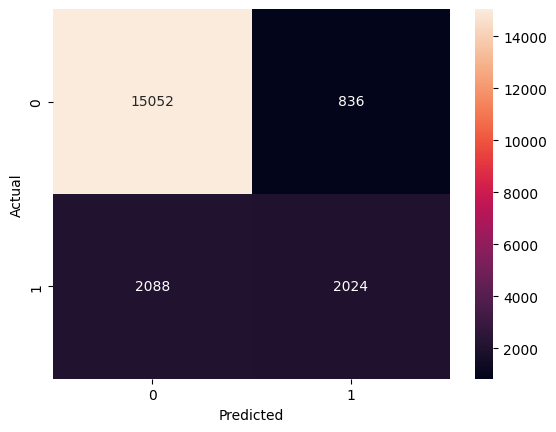

In [16]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

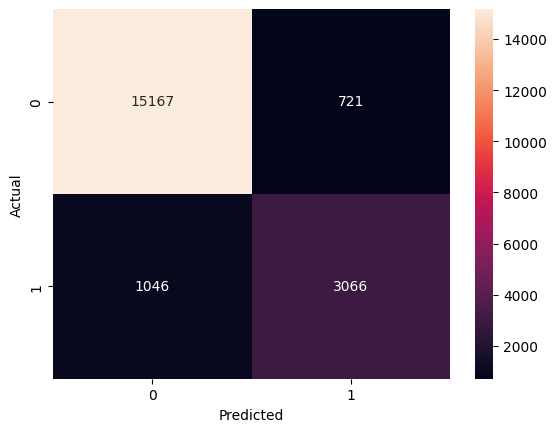

In [15]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

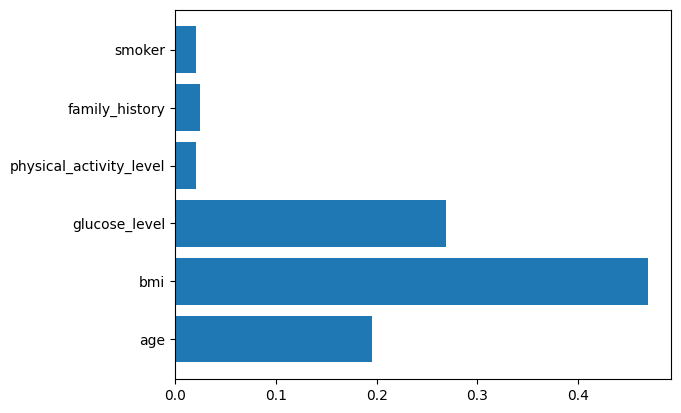

In [17]:
importances = model_rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.show()

In [18]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 5, 'n_estimators': 200}


In [24]:
from sklearn.model_selection import GridSearchCV

params = {'n_estimators': [200, 300],'max_depth': [10, 20],'min_samples_split': [2, 5],}

grid = GridSearchCV(RandomForestClassifier(class_weight='balanced'),params, cv=3,scoring='recall')

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.91      0.94     15888
           1       0.72      0.86      0.79      4112

    accuracy                           0.90     20000
   macro avg       0.84      0.89      0.86     20000
weighted avg       0.91      0.90      0.91     20000



In [26]:
y_prob = best_model.predict_proba(X_test)[:,1]

y_pred_new = (y_prob > 0.3).astype(int)

In [28]:
print("Old:")
print(classification_report(y_test, y_pred))

print("New Threshold:")
print(classification_report(y_test, y_pred_new))

Old:
              precision    recall  f1-score   support

           0       0.96      0.91      0.94     15888
           1       0.72      0.86      0.79      4112

    accuracy                           0.90     20000
   macro avg       0.84      0.89      0.86     20000
weighted avg       0.91      0.90      0.91     20000

New Threshold:
              precision    recall  f1-score   support

           0       0.98      0.81      0.89     15888
           1       0.56      0.95      0.71      4112

    accuracy                           0.84     20000
   macro avg       0.77      0.88      0.80     20000
weighted avg       0.90      0.84      0.85     20000



In [29]:
for t in [0.4, 0.45, 0.5]:
    y_pred_temp = (y_prob > t).astype(int)
    print(f"Threshold = {t}")
    print(classification_report(y_test, y_pred_temp))
    print("-"*50)

Threshold = 0.4
              precision    recall  f1-score   support

           0       0.97      0.89      0.93     15888
           1       0.67      0.89      0.76      4112

    accuracy                           0.89     20000
   macro avg       0.82      0.89      0.84     20000
weighted avg       0.91      0.89      0.89     20000

--------------------------------------------------
Threshold = 0.45
              precision    recall  f1-score   support

           0       0.96      0.91      0.94     15888
           1       0.72      0.87      0.78      4112

    accuracy                           0.90     20000
   macro avg       0.84      0.89      0.86     20000
weighted avg       0.91      0.90      0.91     20000

--------------------------------------------------
Threshold = 0.5
              precision    recall  f1-score   support

           0       0.96      0.91      0.94     15888
           1       0.72      0.86      0.79      4112

    accuracy                   

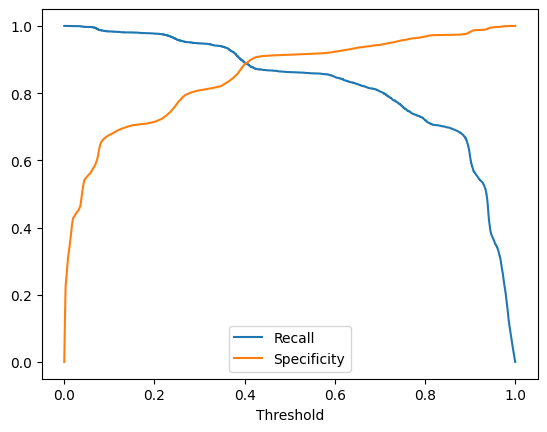

In [30]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(thresholds, tpr, label="Recall")
plt.plot(thresholds, 1 - fpr, label="Specificity")
plt.xlabel("Threshold")
plt.legend()
plt.show()

In [33]:
import joblib

# save model
joblib.dump(best_model, "model.pkl")

# save encoder
joblib.dump(le, "encoder.pkl")

# save threshold
joblib.dump(0.45, "threshold.pkl")

# save feature names
joblib.dump(X.columns.tolist(), "features.pkl")

['features.pkl']